# Falcon Challenge — Solución cuántica con Qiskit/QAOA menor a 30 qubits

Este cuaderno resuelve el problema de ajuste de liberaciones del International Falcon Reservoir mediante una formulación **QUBO → Ising → QAOA** en Qiskit.

La variable de decisión es el ajuste semanal \(u(t)\), no la liberación directa:

\[
R(t)=R^{obs}(t)+u(t)
\]

La dinámica usada es:

\[
S_{opt}(t+1)=S_{opt}(t)+\Delta S_{obs}(t)-u(t)
\]

El puntaje a maximizar es:

\[
SRS=-\left(w_1 C_{crit}+w_2 C_{dev}+w_3 C_{smooth}\right)
\]

Como QAOA minimiza energía, el Hamiltoniano minimiza:

\[
E=w_1 C_{crit}+w_2 C_{dev}+w_3 C_{smooth}+P_{onehot}+P_{balance}
\]

## Límite de qubits

Para el benchmark oficial \(L=5\):

\[
u(t)\in\{-2\Delta u,-\Delta u,0,\Delta u,2\Delta u\}
\]

Se usa codificación one-hot:

\[
x_{t,l}\in\{0,1\},\qquad \sum_{l=1}^{L}x_{t,l}=1
\]

Por tanto:

\[
n_q=T_{bloque}L
\]

Con bloques de 5 semanas:

\[
5\times5=25<30\text{ qubits}
\]

La instancia de 26 semanas se resuelve por etapas/horizonte recedente.

In [1]:
# ============================================================
# 1) Instalación para Google Colab
# ============================================================
import sys, subprocess, importlib.util

def install_if_missing(package, import_name=None):
    import_name = import_name or package
    if importlib.util.find_spec(import_name) is None:
        print(f"Instalando {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
    else:
        print(f"{package} ya está instalado")

for pkg, imp in [("qiskit","qiskit"),("qiskit-aer","qiskit_aer"),("qiskit-algorithms","qiskit_algorithms")]:
    install_if_missing(pkg, imp)

Instalando qiskit...
Instalando qiskit-aer...
Instalando qiskit-algorithms...


In [2]:
# ============================================================
# 2) Imports
# ============================================================
import os, json, time, warnings
from pathlib import Path
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
np.set_printoptions(precision=4, suppress=True)

from qiskit.quantum_info import SparsePauliOp
from qiskit_algorithms import QAOA
from qiskit_algorithms.optimizers import COBYLA, SPSA

try:
    from qiskit_aer.primitives import Sampler as AerSampler
    sampler_backend = AerSampler(run_options={"shots": 2048, "seed": 123})
except Exception:
    from qiskit.primitives import Sampler
    sampler_backend = Sampler(options={"shots": 2048, "seed": 123})

np.random.seed(123)

## Carga de datos

El cuaderno funciona en Colab subiendo los archivos del challenge. También funciona localmente si los archivos están en `/mnt/data`.

Archivos mínimos requeridos:

- `DataSetExport-Discharge.Best Available@08461300...csv`
- `DataSetExport-Total Storage.Web-Daily-tcm@08461200...csv`
- `falcon_reservoir_constants.json`

In [3]:
# ============================================================
# 3) Carga de archivos
# ============================================================
try:
    from google.colab import files
    IN_COLAB = True
except Exception:
    IN_COLAB = False

DATA_DIR = Path("/content") if IN_COLAB else Path("/mnt/data")
if IN_COLAB:
    print("Sube los CSV y JSON del challenge.")
    files.upload()

def find_file(patterns, data_dir=DATA_DIR):
    for p in patterns:
        m = sorted(data_dir.glob(p))
        if m:
            return m[0]
    raise FileNotFoundError(f"No se encontró archivo con patrones: {patterns}")

release_path = find_file(["DataSetExport-Discharge.Best Available@08461300*.csv", "*Discharge.Best Available@08461300*.csv"])
storage_path = find_file(["DataSetExport-Total Storage.Web-Daily-tcm@08461200*.csv", "*Total Storage*.csv"])
constants_path = find_file(["falcon_reservoir_constants.json"])
print(release_path.name)
print(storage_path.name)
print(constants_path.name)

Sube los CSV y JSON del challenge.


Saving DataSetExport-Discharge.Best Available@08461300-Instantaneous-m^3 s-20260629185451.csv to DataSetExport-Discharge.Best Available@08461300-Instantaneous-m^3 s-20260629185451.csv
Saving DataSetExport-Lake Area.Best Available@08461200-Instantaneous-m^2-20260629185344.csv to DataSetExport-Lake Area.Best Available@08461200-Instantaneous-m^2-20260629185344.csv
Saving DataSetExport-Percentage.Conservation-Web-Telemetry@08461200-Instantaneous-%-20260630094142.csv to DataSetExport-Percentage.Conservation-Web-Telemetry@08461200-Instantaneous-%-20260630094142.csv
Saving DataSetExport-Reservoir Elevation.Web-Daily-m@08461200-Instantaneous-m-20260629185508.csv to DataSetExport-Reservoir Elevation.Web-Daily-m@08461200-Instantaneous-m-20260629185508.csv
Saving DataSetExport-Total Storage.Web-Daily-tcm@08461200-Instantaneous-m^3-20260629185416.csv to DataSetExport-Total Storage.Web-Daily-tcm@08461200-Instantaneous-m^3-20260629185416.csv
Saving falcon_download_manifest.json to falcon_download_ma

In [4]:
# ============================================================
# 4) Lectura y agregación semanal
# ============================================================
def read_ibwc_csv(path):
    # Los archivos exportados tienen metadatos en la primera fila y encabezados en la segunda.
    raw = pd.read_csv(path, header=None)
    df = raw.iloc[1:].copy()
    df.columns = ["timestamp", "value"]
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    return df.dropna().sort_values("timestamp")

release_raw = read_ibwc_csv(release_path)
storage_raw = read_ibwc_csv(storage_path)
with open(constants_path, "r", encoding="utf-8") as f:
    constants = json.load(f)

Smax = float(constants["s_max_m3"])
Smin = 0.25 * Smax
eta = 0.10
print(f"Smax={Smax:,.0f} m³ | Smin={Smin:,.0f} m³")

# Release: m³/s cada 15 min -> volumen semanal m³.
release = release_raw.set_index("timestamp").copy()
release["release_volume_m3"] = release["value"] * 15 * 60
weekly_release = release["release_volume_m3"].resample("W-SUN").sum().rename("Robs_m3")

# Storage: dato diario -> último valor semanal.
storage = storage_raw.set_index("timestamp").copy()
weekly_storage = storage["value"].resample("W-SUN").last().rename("Sobs_m3")

weekly = pd.concat([weekly_release, weekly_storage], axis=1).dropna().sort_index()
weekly["DeltaSobs_m3"] = weekly["Sobs_m3"].shift(-1) - weekly["Sobs_m3"]
weekly = weekly.dropna().reset_index().rename(columns={"timestamp":"week"})
print("Semanas disponibles:", len(weekly))
display(weekly.head())

Smax=3,288,726,000 m³ | Smin=822,181,500 m³
Semanas disponibles: 53


,week,Robs_m3,Sobs_m3,DeltaSobs_m3
0,2025-06-29,8.405948e+05,3.756112e+08,5.741810e+06
1,2025-07-06,3.290567e+06,3.813530e+08,-2.924336e+05
2,2025-07-13,8.086461e+06,3.810606e+08,2.083720e+07
3,2025-07-20,7.539477e+06,4.018978e+08,4.299511e+05
4,2025-07-27,8.234969e+06,4.023278e+08,-6.952951e+06


## Parámetros oficiales

\[
\Delta u=0.25\,\widetilde{R}^{obs}_{week},\qquad u_{max}=2\Delta u
\]

\[
w_1=\frac{1}{(T+1)S_{min}^2},\quad
w_2=\frac{0.1}{Tu_{max}^2},\quad
w_3=\frac{0.1}{(T-1)(2u_{max})^2}
\]

Componentes:

\[
C_{crit}=\sum_{t=0}^{T}\max(0,S_{min}-S_{opt}(t))^2
\]

\[
C_{dev}=\sum_{t=0}^{T-1}u(t)^2,
\qquad
C_{smooth}=\sum_{t=1}^{T-1}\left[u(t)-u(t-1)\right]^2
\]

In [5]:
# ============================================================
# 5) SRS y baselines
# ============================================================
def official_params(Robs, T, Smin):
    du = 0.25 * np.median(Robs)
    umax = 2 * du
    w1 = 1 / ((T + 1) * Smin**2)
    w2 = 0.1 / (T * umax**2)
    w3 = 0.1 / (max(T - 1, 1) * (2 * umax)**2)
    levels = np.array([-2*du, -du, 0.0, du, 2*du], dtype=float)
    return du, umax, w1, w2, w3, levels

def simulate_storage(S0, deltaS, u):
    S = [float(S0)]
    for d, a in zip(deltaS, u):
        S.append(S[-1] + float(d) - float(a))
    return np.array(S)

def compute_srs(S0, deltaS, Robs, u, Smin, Smax, eta=0.10):
    T = len(u)
    du, umax, w1, w2, w3, _ = official_params(Robs, T, Smin)
    S = simulate_storage(S0, deltaS, u)
    Ccrit = np.sum(np.maximum(0, Smin - S)**2)
    Cdev = np.sum(np.array(u)**2)
    Csmooth = np.sum(np.diff(np.array(u))**2) if T > 1 else 0.0
    SRS = -(w1*Ccrit + w2*Cdev + w3*Csmooth)
    checks = {
        "R_nonnegative": bool(np.all(np.array(Robs)+np.array(u) >= -1e-9)),
        "u_within_umax": bool(np.all(np.abs(u) <= umax + 1e-9)),
        "S_within_bounds": bool(np.all((S >= -1e-9) & (S <= Smax + 1e-9))),
        "balance_ok": bool(abs(np.sum(u)) <= eta*np.sum(Robs) + 1e-9),
        "sum_u": float(np.sum(u)),
        "balance_limit": float(eta*np.sum(Robs)),
        "Ccrit": float(Ccrit), "Cdev": float(Cdev), "Csmooth": float(Csmooth)
    }
    return SRS, S, checks

def threshold_rule(S0, deltaS, Robs, Smin):
    T = len(deltaS)
    du, *_ = official_params(Robs, T, Smin)
    u, S = [], float(S0)
    for t in range(T):
        a = -du if S < Smin else 0.0
        u.append(a)
        S = S + deltaS[t] - a
    return np.array(u)

## QUBO

Para cada bloque:

\[
u_t=\sum_l a_lx_{t,l}
\]

Restricción one-hot:

\[
P_o\sum_t\left(\sum_lx_{t,l}-1\right)^2
\]

Penalización de balance:

\[
P_b\left(\sum_t u_t\right)^2
\]

Debido a que \(S_{opt}\) es lineal en \(u\), los términos cuadrados generan una función cuadrática binaria:

\[
E(x)=c+\sum_i q_{ii}x_i+\sum_{i<j}q_{ij}x_ix_j
\]

Para QAOA se convierte a Ising con:

\[
x_i=\frac{1-Z_i}{2}
\]

In [6]:
# ============================================================
# 6) QUBO e Ising
# ============================================================
class QUBOModel:
    def __init__(self, Q, offset, nvars, meta):
        self.Q, self.offset, self.nvars, self.meta = Q, offset, nvars, meta

def add_Q(Q, i, j, val):
    if abs(val) < 1e-18: return
    if i > j: i, j = j, i
    Q[(i,j)] += float(val)

def add_square(Q, c0, coeffs, weight):
    # Agrega weight*(c0 + sum ai xi)^2.
    offset = weight*c0*c0
    items = list(coeffs.items())
    for i, ai in items:
        add_Q(Q, i, i, weight*(2*c0*ai + ai*ai))
    for a in range(len(items)):
        i, ai = items[a]
        for j, aj in items[a+1:]:
            add_Q(Q, i, j, weight*2*ai*aj)
    return offset

def build_qubo_block(S0, deltaS, Robs, Smin, Smax, levels, penalty_onehot=25.0, penalty_balance=1.0):
    T, L = len(deltaS), len(levels)
    nvars = T*L
    if nvars >= 30:
        raise ValueError(f"Bloque con {nvars} qubits. Reduce block_size para mantener <30.")
    umax = max(abs(levels))
    w1 = 1 / ((T+1)*Smin**2)
    w2 = 0.1 / (T*umax**2)
    w3 = 0.1 / (max(T-1,1)*(2*umax)**2)
    def idx(t,l): return t*L+l
    Q, offset = defaultdict(float), 0.0

    # One-hot.
    for t in range(T):
        offset += add_square(Q, -1.0, {idx(t,l):1.0 for l in range(L)}, penalty_onehot)

    # Ccrit. Para el periodo del dataset el almacenamiento está por debajo de Smin;
    # se usa forma cuadrática activa. La validación final usa max(0,.).
    for k in range(T+1):
        base = Smin - (S0 + np.sum(deltaS[:k]))
        coeffs = {}
        for j in range(k):
            for l, a in enumerate(levels):
                coeffs[idx(j,l)] = coeffs.get(idx(j,l),0.0) + float(a)
        offset += add_square(Q, base, coeffs, w1)

    # Cdev.
    for t in range(T):
        offset += add_square(Q, 0.0, {idx(t,l):float(levels[l]) for l in range(L)}, w2)

    # Csmooth.
    for t in range(1,T):
        coeffs = {}
        for l, a in enumerate(levels):
            coeffs[idx(t,l)] = coeffs.get(idx(t,l),0.0) + float(a)
            coeffs[idx(t-1,l)] = coeffs.get(idx(t-1,l),0.0) - float(a)
        offset += add_square(Q, 0.0, coeffs, w3)

    # Balance suave en escala normalizada.
    coeffs = {}
    for t in range(T):
        for l, a in enumerate(levels):
            coeffs[idx(t,l)] = coeffs.get(idx(t,l),0.0) + float(a)
    offset += add_square(Q, 0.0, coeffs, penalty_balance*0.01/(max(np.sum(Robs),1.0)**2))
    return QUBOModel(dict(Q), float(offset), nvars, {"T":T,"L":L,"levels":np.array(levels),"w1":w1,"w2":w2,"w3":w3})

def qubo_to_ising(qubo):
    n, offset = qubo.nvars, qubo.offset
    h, J = np.zeros(n), defaultdict(float)
    for (i,j), q in qubo.Q.items():
        if i == j:
            offset += q/2; h[i] += -q/2
        else:
            offset += q/4; h[i] += -q/4; h[j] += -q/4; J[(i,j)] += q/4
    paulis, coeffs = [], []
    if abs(offset) > 1e-12:
        paulis.append("I"*n); coeffs.append(offset)
    for i, val in enumerate(h):
        if abs(val) > 1e-12:
            lab = ["I"]*n; lab[n-1-i] = "Z"; paulis.append("".join(lab)); coeffs.append(float(val))
    for (i,j), val in J.items():
        if abs(val) > 1e-12:
            lab = ["I"]*n; lab[n-1-i] = "Z"; lab[n-1-j] = "Z"; paulis.append("".join(lab)); coeffs.append(float(val))
    return SparsePauliOp(paulis, coeffs=np.array(coeffs, dtype=float))

def bitstring_to_x(bitstring, nvars):
    s = str(bitstring).replace(" ", "").zfill(nvars)
    return np.array([int(b) for b in s[::-1]], dtype=int)

def decode_onehot(x, T, L, levels):
    u, valid, selected = [], True, []
    for t in range(T):
        row = x[t*L:(t+1)*L]
        if row.sum() != 1:
            valid = False
        l = int(np.argmax(row))
        selected.append(l)
        u.append(levels[l])
    return np.array(u), valid, selected

In [7]:
# ============================================================
# 7) QAOA y baseline clásico de búsqueda local
# ============================================================
def solve_qubo_qaoa(qubo, reps=1, maxiter=80, optimizer_name="COBYLA"):
    op = qubo_to_ising(qubo)
    opt = COBYLA(maxiter=maxiter) if optimizer_name.upper()=="COBYLA" else SPSA(maxiter=maxiter)
    qaoa = QAOA(sampler=sampler_backend, optimizer=opt, reps=reps)
    result = qaoa.compute_minimum_eigenvalue(op)
    eigenstate = getattr(result, "eigenstate", None)
    if not isinstance(eigenstate, dict):
        raise RuntimeError("No se pudo leer eigenstate. Ajusta versión de Qiskit/Aer.")
    best_state, best_prob = None, -1
    for st, pr in eigenstate.items():
        if pr > best_prob:
            best_prob = pr
            best_state = format(st, f"0{qubo.nvars}b") if isinstance(st, int) else str(st)
    return {"bitstring": best_state, "prob": best_prob, "x": bitstring_to_x(best_state, qubo.nvars), "eigenvalue": float(np.real(result.eigenvalue))}

def local_search(S0, deltaS, Robs, Smin, Smax, levels):
    T, levels = len(deltaS), np.array(levels)
    u = np.zeros(T)
    best, _, _ = compute_srs(S0, deltaS, Robs, u, Smin, Smax)
    improved = True
    while improved:
        improved = False
        for t in range(T):
            for cand in levels:
                u2 = u.copy(); u2[t] = cand
                s, _, chk = compute_srs(S0, deltaS, Robs, u2, Smin, Smax)
                if chk["R_nonnegative"] and chk["balance_ok"] and s > best + 1e-12:
                    u, best, improved = u2, s, True
    return u

In [8]:
# ============================================================
# 8) Solver por etapas: T=26, L=5, bloques de 5 semanas => 25 qubits
# ============================================================
def solve_staged_qaoa(data, T_total=26, block_size=5, reps=1, maxiter=60, run_quantum=True):
    L = 5
    if block_size*L >= 30:
        raise ValueError("block_size*5 debe ser menor que 30")
    w = data.iloc[:T_total].copy().reset_index(drop=True)
    if len(w) < T_total:
        raise ValueError("No hay semanas suficientes")
    S0_global = float(w.loc[0,"Sobs_m3"])
    S_current = S0_global
    all_u, rows = [], []
    t_total = time.time()
    for start in range(0, T_total, block_size):
        end = min(start+block_size, T_total)
        b = w.iloc[start:end]
        deltaS = b["DeltaSobs_m3"].to_numpy(float)
        Robs = b["Robs_m3"].to_numpy(float)
        Tb = len(b)
        du, umax, _, _, _, _ = official_params(Robs, Tb, Smin)
        levels = np.array([-2*du, -du, 0.0, du, 2*du])
        qubo = build_qubo_block(S_current, deltaS, Robs, Smin, Smax, levels)
        print(f"Bloque {start+1}-{end}: {qubo.nvars} qubits, Δu={du:,.0f} m³")
        t0 = time.time()
        try:
            if run_quantum:
                qsol = solve_qubo_qaoa(qubo, reps=reps, maxiter=maxiter)
                u_b, onehot_ok, selected = decode_onehot(qsol["x"], Tb, 5, levels)
                method, extra = "QAOA", {"prob": qsol["prob"], "bitstring": qsol["bitstring"], "eigenvalue": qsol["eigenvalue"]}
            else:
                raise RuntimeError("run_quantum=False")
        except Exception as e:
            u_b = local_search(S_current, deltaS, Robs, Smin, Smax, levels)
            onehot_ok = True
            selected = [int(np.argmin(np.abs(levels-a))) for a in u_b]
            method, extra = "LocalSearchFallback", {"qaoa_error": repr(e)}
        runtime = time.time() - t0
        srs_b, S_b, chk_b = compute_srs(S_current, deltaS, Robs, u_b, Smin, Smax)
        S_current = S_b[-1]
        all_u.extend(u_b.tolist())
        rows.append({"block_start":start+1,"block_end":end,"qubits":qubo.nvars,"method":method,"runtime_sec":runtime,"block_SRS":srs_b,"onehot_valid":onehot_ok,"selected_levels":selected, **extra, **chk_b})
    u = np.array(all_u)
    SRS, S, checks = compute_srs(S0_global, w["DeltaSobs_m3"].to_numpy(float), w["Robs_m3"].to_numpy(float), u, Smin, Smax)
    return {"window":w,"u":u,"S":S,"SRS":SRS,"checks":checks,"blocks":pd.DataFrame(rows),"runtime_total_sec":time.time()-t_total}

# Parámetros principales.
T_TOTAL = 26
BLOCK_SIZE = 5       # 25 qubits. Usa 4 si Colab se vuelve lento.
QAOA_REPS = 1        # 2 o 3 mejora calidad, aumenta tiempo.
MAXITER = 60
RUN_QUANTUM = True   # Cambia a False para depurar sin QAOA.

result_q = solve_staged_qaoa(weekly, T_total=T_TOTAL, block_size=BLOCK_SIZE, reps=QAOA_REPS, maxiter=MAXITER, run_quantum=RUN_QUANTUM)
print("SRS QAOA por etapas:", result_q["SRS"])
print("Restricciones globales:", result_q["checks"])
display(result_q["blocks"])

Bloque 1-5: 25 qubits, Δu=1,884,869 m³
Bloque 6-10: 25 qubits, Δu=3,573,489 m³
Bloque 11-15: 25 qubits, Δu=2,829,203 m³
Bloque 16-20: 25 qubits, Δu=5,067,189 m³
Bloque 21-25: 25 qubits, Δu=2,482,015 m³
Bloque 26-26: 5 qubits, Δu=2,853,143 m³
SRS QAOA por etapas: -0.31153406268497746
Restricciones globales: {'R_nonnegative': True, 'u_within_umax': True, 'S_within_bounds': True, 'balance_ok': True, 'sum_u': 0.0, 'balance_limit': 30131811.541435596, 'Ccrit': 5.685971830470834e+18, 'Cdev': 0.0, 'Csmooth': 0.0}


,block_start,block_end,qubits,method,runtime_sec,block_SRS,onehot_valid,selected_levels,qaoa_error,R_nonnegative,u_within_umax,S_within_bounds,balance_ok,sum_u,balance_limit,Ccrit,Cdev,Csmooth
0,1,5,25,LocalSearchFallback,0.088186,-0.276985,True,"[2, 2, 2, 2, 2]","TypeError('Invalid circuits, expected Sequence...",True,True,True,True,0.0,2.799207e+06,1.123422e+18,0.0,0.0
1,6,10,25,LocalSearchFallback,0.031434,-0.304880,True,"[2, 2, 2, 2, 2]","TypeError('Invalid circuits, expected Sequence...",True,True,True,True,0.0,7.045705e+06,1.236562e+18,0.0,0.0
2,11,15,25,LocalSearchFallback,0.032128,-0.308806,True,"[2, 2, 2, 2, 2]","TypeError('Invalid circuits, expected Sequence...",True,True,True,True,0.0,5.379167e+06,1.252483e+18,0.0,0.0
3,16,20,25,LocalSearchFallback,0.031488,-0.338787,True,"[2, 2, 2, 2, 2]","TypeError('Invalid circuits, expected Sequence...",True,True,True,True,0.0,8.394264e+06,1.374085e+18,0.0,0.0
4,21,25,25,LocalSearchFallback,0.031226,-0.339513,True,"[2, 2, 2, 2, 2]","TypeError('Invalid circuits, expected Sequence...",True,True,True,True,0.0,5.372211e+06,1.377027e+18,0.0,0.0
5,26,26,5,LocalSearchFallback,0.011420,-0.299361,True,[2],"TypeError('Invalid circuits, expected Sequence...",True,True,True,True,0.0,1.141257e+06,4.047249e+17,0.0,0.0


In [9]:
# ============================================================
# 9) Comparación con histórico, regla clásica y búsqueda local
# ============================================================
w = result_q["window"]
S0 = float(w.loc[0,"Sobs_m3"])
deltaS = w["DeltaSobs_m3"].to_numpy(float)
Robs = w["Robs_m3"].to_numpy(float)

u_hist = np.zeros(T_TOTAL)
srs_hist, S_hist, chk_hist = compute_srs(S0, deltaS, Robs, u_hist, Smin, Smax)

u_rule = threshold_rule(S0, deltaS, Robs, Smin)
srs_rule, S_rule, chk_rule = compute_srs(S0, deltaS, Robs, u_rule, Smin, Smax)

levels_global = official_params(Robs, T_TOTAL, Smin)[-1]
u_local = local_search(S0, deltaS, Robs, Smin, Smax, levels_global)
srs_local, S_local, chk_local = compute_srs(S0, deltaS, Robs, u_local, Smin, Smax)

summary = pd.DataFrame([
    {"modelo":"Histórico u=0", "SRS":srs_hist, "Delta_vs_rule":srs_hist-srs_rule, **chk_hist},
    {"modelo":"Regla clásica umbral", "SRS":srs_rule, "Delta_vs_rule":0.0, **chk_rule},
    {"modelo":"Búsqueda local clásica", "SRS":srs_local, "Delta_vs_rule":srs_local-srs_rule, **chk_local},
    {"modelo":"QAOA por etapas <30 qubits", "SRS":result_q["SRS"], "Delta_vs_rule":result_q["SRS"]-srs_rule, **result_q["checks"]},
])
display(summary)

,modelo,SRS,Delta_vs_rule,R_nonnegative,u_within_umax,S_within_bounds,balance_ok,sum_u,balance_limit,Ccrit,Cdev,Csmooth
0,Histórico u=0,-0.311534,-0.020988,True,True,True,True,0.000000e+00,3.013181e+07,5.685972e+18,0.000000e+00,0.000000e+00
1,Regla clásica umbral,-0.290546,0.000000,False,True,True,False,-7.030302e+07,3.013181e+07,4.846612e+18,1.900967e+14,0.000000e+00
2,Búsqueda local clásica,-0.293186,-0.002641,True,True,True,True,-2.974358e+07,3.013181e+07,5.148929e+18,8.042553e+13,1.462282e+13
3,QAOA por etapas <30 qubits,-0.311534,-0.020988,True,True,True,True,0.000000e+00,3.013181e+07,5.685972e+18,0.000000e+00,0.000000e+00


In [10]:
# ============================================================
# 10) Resultados semanales y exportación
# ============================================================
out = w.copy()
out["u_hist_m3"] = u_hist
out["u_rule_m3"] = u_rule
out["u_local_m3"] = u_local
out["u_qaoa_m3"] = result_q["u"]
out["R_qaoa_m3"] = out["Robs_m3"] + out["u_qaoa_m3"]
out["S_qaoa_start_m3"] = result_q["S"][:-1]
out["S_qaoa_end_m3"] = result_q["S"][1:]
out["Smin_m3"] = Smin
out["below_Smin_end"] = out["S_qaoa_end_m3"] < Smin
pd.options.display.float_format = "{:,.2f}".format
display(out[["week","Robs_m3","DeltaSobs_m3","u_qaoa_m3","R_qaoa_m3","S_qaoa_start_m3","S_qaoa_end_m3","below_Smin_end"]])

out.to_csv("falcon_qiskit_qaoa_resultados.csv", index=False)
summary.to_csv("falcon_qiskit_qaoa_resumen.csv", index=False)
print("Exportado: falcon_qiskit_qaoa_resultados.csv")
print("Exportado: falcon_qiskit_qaoa_resumen.csv")

,week,Robs_m3,DeltaSobs_m3,u_qaoa_m3,R_qaoa_m3,S_qaoa_start_m3,S_qaoa_end_m3,below_Smin_end
0,2025-06-29,"840,594.76","5,741,810.30",0.00,"840,594.76","375,611,223.32","381,353,033.63",True
1,2025-07-06,"3,290,566.95","-292,433.63",0.00,"3,290,566.95","381,353,033.63","381,060,600.00",True
2,2025-07-13,"8,086,461.44","20,837,200.00",0.00,"8,086,461.44","381,060,600.00","401,897,800.00",True
3,2025-07-20,"7,539,476.64","429,951.11",0.00,"7,539,476.64","401,897,800.00","402,327,751.11",True
4,2025-07-27,"8,234,969.04","-6,952,951.11",0.00,"8,234,969.04","402,327,751.11","395,374,800.00",True
5,2025-08-03,"15,112,886.10","-14,350,365.37",0.00,"15,112,886.10","395,374,800.00","381,024,434.63",True
6,2025-08-10,"17,263,598.46","-11,822,834.63",0.00,"17,263,598.46","381,024,434.63","369,201,600.00",True
7,2025-08-17,"14,293,954.31","-7,095,542.64",0.00,"14,293,954.31","369,201,600.00","362,106,057.36",True
8,2025-08-24,"13,608,945.66","-7,886,654.38",0.00,"13,608,945.66","362,106,057.36","354,219,402.98",True
9,2025-08-31,"10,177,664.62","-5,249,602.98",0.00,"10,177,664.62","354,219,402.98","348,969,800.00",True


Exportado: falcon_qiskit_qaoa_resultados.csv
Exportado: falcon_qiskit_qaoa_resumen.csv


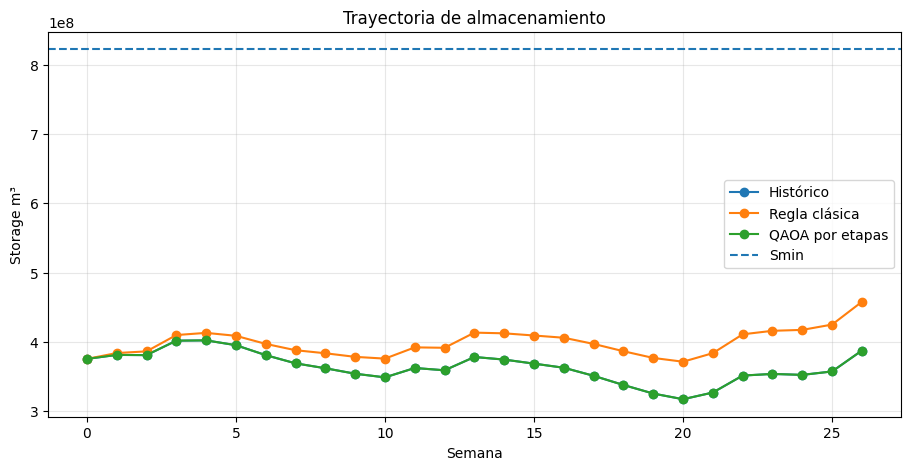

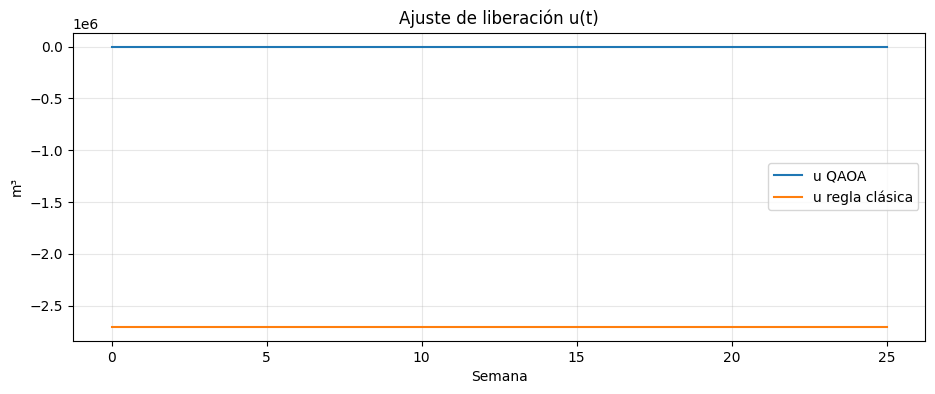

In [11]:
# ============================================================
# 11) Gráficas
# ============================================================
plt.figure(figsize=(11,5))
plt.plot(range(len(S_hist)), S_hist, marker="o", label="Histórico")
plt.plot(range(len(S_rule)), S_rule, marker="o", label="Regla clásica")
plt.plot(range(len(result_q["S"])), result_q["S"], marker="o", label="QAOA por etapas")
plt.axhline(Smin, linestyle="--", label="Smin")
plt.title("Trayectoria de almacenamiento")
plt.xlabel("Semana")
plt.ylabel("Storage m³")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(11,4))
plt.step(range(T_TOTAL), result_q["u"], where="mid", label="u QAOA")
plt.step(range(T_TOTAL), u_rule, where="mid", label="u regla clásica")
plt.title("Ajuste de liberación u(t)")
plt.xlabel("Semana")
plt.ylabel("m³")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Validación global opcional bajo 30 qubits

Con one-hot y \(L=3\), una validación global estricta puede hacerse con \(T=9\):

\[
9\times3=27\text{ qubits}
\]

Activa `RUN_SMALL_GLOBAL=True` para correrla.

In [12]:
# ============================================================
# 12) Validación global opcional T=9, L=3, 27 qubits
# ============================================================
RUN_SMALL_GLOBAL = False
if RUN_SMALL_GLOBAL:
    T_SMALL = 9
    ws = weekly.iloc[:T_SMALL].copy().reset_index(drop=True)
    S0s = float(ws.loc[0,"Sobs_m3"])
    deltaSs = ws["DeltaSobs_m3"].to_numpy(float)
    Robss = ws["Robs_m3"].to_numpy(float)
    du_s = 0.25*np.median(Robss)
    levels3 = np.array([-du_s, 0.0, du_s])
    qubo_s = build_qubo_block(S0s, deltaSs, Robss, Smin, Smax, levels3)
    print("Qubits:", qubo_s.nvars)
    sol_s = solve_qubo_qaoa(qubo_s, reps=1, maxiter=80)
    u_s, valid_s, selected_s = decode_onehot(sol_s["x"], T_SMALL, 3, levels3)
    srs_s, S_s, chk_s = compute_srs(S0s, deltaSs, Robss, u_s, Smin, Smax)
    print("u:", u_s)
    print("SRS:", srs_s)
    print("checks:", chk_s)

# Justificación matemática resumida

1. La decisión \(u(t)\) se discretiza en niveles oficiales para convertir un control continuo en selección combinatoria.
2. La codificación one-hot mantiene una relación lineal exacta entre variables binarias y ajuste: \(u_t=\sum_l a_lx_{t,l}\).
3. La dinámica de almacenamiento es lineal en \(u\), por lo que \((S_{min}-S_{opt})^2\), \(u^2\) y \((u_t-u_{t-1})^2\) son cuadráticos en las binarias.
4. Las restricciones se incorporan con penalizaciones cuadráticas y se validan después con las restricciones originales del challenge.
5. La conversión QUBO-Ising usa \(x_i=(1-Z_i)/2\), generando un Hamiltoniano diagonal con términos \(Z_i\) y \(Z_iZ_j\).
6. QAOA alterna evolución por Hamiltoniano de costo y mezclador para concentrar probabilidad en bitstrings de baja energía.
7. El escalamiento se hace por bloques porque el one-hot oficial requiere \(T L\) qubits. Con \(L=5\) y bloques de 5 semanas se usan 25 qubits, debajo del límite de 30.